<a href="https://colab.research.google.com/github/OptimizationExpert/Andrew6rant/blob/main/Distance_Exceed_of_CVRP_CP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Developed by Alireza Soroudi
alireza.soroudi@gmail.com

Linkedin News letter : https://www.linkedin.com/newsletters/optimization-in-open-source-6874020019009859585/

Git hub: https://github.com/OptimizationExpert/Pyomo

In [6]:
import pandas as pd
!pip install ortools
from ortools.sat.python import cp_model
import matplotlib.pyplot as plt # Data visualization
import random
import numpy as np

{1: (0.5, 0.5, 0),
 2: (0.0053182789442243195, 0.9058164612105243, 12),
 3: (0.8615467810533106, 0.10179035205528153, 9),
 4: (0.27913143788969086, 0.48530198265977553, 14),
 5: (0.8641080412334292, 0.3082360999656605, 15),
 6: (0.09733631303512358, 0.5019039800580074, 6),
 7: (0.8446362887929324, 0.7895722036450555, 19),
 8: (0.677988293792863, 0.9111672703215296, 17),
 9: (0.16960922276766344, 0.011281856804558066, 2),
 10: (0.16261780962937422, 0.9941639424740727, 12),
 11: (0.7015932578563275, 0.34850443042485146, 6),
 12: (0.3915379413680182, 0.22677777211354055, 10),
 13: (0.7931042957954834, 0.8712603884880403, 19),
 14: (0.7957329955290611, 0.9199418944029899, 5),
 15: (0.5896992609889267, 0.06615307230413481, 1),
 16: (0.7378798382802317, 0.7267579400581922, 5),
 17: (0.48958232024217774, 0.7102419889908125, 14),
 18: (0.2369245117651908, 0.5120560959628423, 3),
 19: (0.12417722882629478, 0.13469281686550616, 20),
 20: (0.18225685779185608, 0.2555148123037636, 13),
 21: (0.910

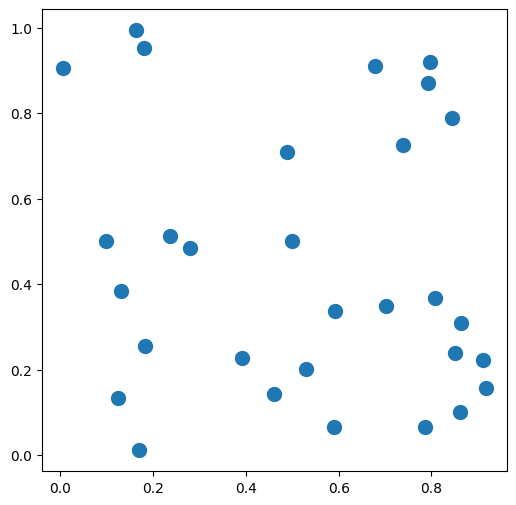

In [7]:
n = 30
depot = 1
nodes = [i for i in range(1,1+n)]
data = {}
for n in nodes:
  data[n]=(random.random(),random.random(), random.randint(1,20))
data[depot]=(0.5, 0.5,0)
cars = range(4)
plt.figure(figsize=(6,6))
X= [data[n][0] for n in nodes]
Y= [data[n][1] for n in nodes]
plt.scatter(X,Y,s=100)
data

In [8]:
def distance(n:int,m:int,data:dict)-> int:
  x1,y1 = data[n][0],data[n][1]
  x2,y2 = data[m][0],data[m][1]
  return int(100*np.sqrt( (x1-x2)**2+(y1-y2)**2))

distance(1,2,data)
print(nodes)

check = sum(data[n][2] for n in nodes)
print(check)

KOLORS = ['r','k','b','g']

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
301


Capacity  0 100
Capacity  1 190
Capacity  2 130
Capacity  3 70
Min of objective function: 0.0

Distance  0 170
Distance  1 163
Distance  2 174
Distance  3 178


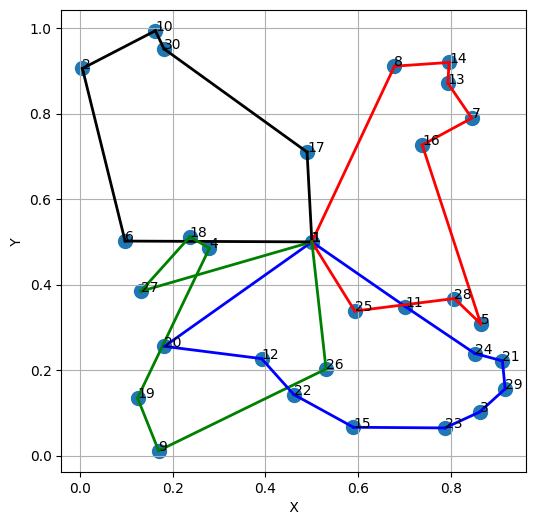

In [14]:
def main() -> None:
    # Creates the model.
    cap = {0:100, 1:190, 2:130, 3:70}
    threshhold = 178
    model = cp_model.CpModel()
    x={(i,j,c):model.NewBoolVar(f"flow_{i}_{j}_{c}") for i in nodes
       for j in nodes for c in cars if i!=j}
    assign = {(i,c): model.NewBoolVar(f"assign_{i}_{c}") for i in nodes for c in cars}
    used_car = {c: model.NewBoolVar(f"used_{c}") for c in cars}
    exceed_car = {c: model.NewBoolVar(f"exceed_{c}") for c in cars}
    exceed_car_dist = {c: model.NewIntVar(0,200,f"exceed_dist_{c}") for c in cars}

    for i in nodes:
      expressions = [assign[i,c] for c in cars]
      model.AddAtLeastOne(expressions)

    for (i,c),v in assign.items():
      model.Add(v<=used_car[c])


    for c in cars:
      model.Add(assign[depot,c]==used_car[c])
      arcs= [ (i,j,v) for (i,j,cc),v in x.items() if cc == c] + [(i,i,assign[i,c].Not()) for i in nodes]
      model.AddCircuit(arcs)


      expressions = [v*data[i][2] for (i,cc),v in assign.items() if c ==cc]
      model.Add(sum(expressions) <= cap[c])
      print('Capacity ', c,cap[c])

    for cc in cars:
        expressions_c = [distance(i,j,data)* v for (i,j,c),v in x.items() if c==cc]
        model.Add(sum(expressions_c) <= threshhold + exceed_car_dist[cc])


    #expressions_of = [distance(i,j,data)* v for (i,j,c),v in x.items() ]
    expressions_of = [ v for c,v in exceed_car_dist.items() ]
    model.minimize(sum(expressions_of))



    # Creates a solver and solves the model.
    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = 90
    status = solver.solve(model)

    if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
        print(f"Min of objective function: {solver.objective_value}\n")
        plt.figure(figsize=(6,6))
        X= [data[n][0] for n in nodes]
        Y= [data[n][1] for n in nodes]
        plt.scatter(X,Y,s=100)

        for (i,j,c),v in x.items():
          if solver.value(v)>0:
              x1,y1 = data[i][0],data[i][1]
              x2,y2 = data[j][0],data[j][1]
              plt.plot([x1,x2],[y1,y2], lw=2, c=KOLORS[c])
              plt.text(x1,y1,s=str(i))

        for cc in cars:
           expressions_c = [distance(i,j,data)* solver.value(v) for (i,j,c),v in x.items() if c==cc]
           print('Distance ', cc, sum(expressions_c))


        plt.xlabel(' X ')
        plt.ylabel(' Y ')
        plt.grid()

    else:
        print("No solution found.")

if __name__ == "__main__":
    main()